# Lab Assignment 4: Binary Classification with Logistic Regression (AI in Healthcare)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/achalzz/ai-healthcare-cset343/blob/main/Lab_Assignment_4_AI_in_Healthcare.ipynb)

**Course:** B.Tech Specialization Elective (4th Year, Sem VII)  
**Course Code:** CSET343 - AI in Healthcare  
**Assignment:** Lab Assignment 4 - Binary Classification with Logistic Regression: Diagnostic Breast Cancer Detection & Clinical Decision Support


In [1]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein environment setup kiya aur binary classification ke required modules import kiye.
# Step 1: NumPy, Pandas, Matplotlib aur Seaborn import kiye.
# Step 2: Sklearn se LogisticRegression, StandardScaler, train_test_split, GridSearchCV import kiye.
# Step 3: Clinical evaluation metrics (accuracy, precision, recall, f1, roc_auc, confusion_matrix) load kiye.
# Step 4: Reproducibility ke liye random seed 42 set kiya.
# ====================================================================
# Setup Dependencies & System Allocation
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Scikit-Learn tools for classification, scaling, metrics, and tuning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, log_loss
)

import warnings
warnings.filterwarnings('ignore')

# Visual styling setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)

print(f"[INFO] Python Version: {sys.version.split()[0]}")
print(f"[INFO] NumPy Version: {np.__version__}")
print(f"[INFO] Pandas Version: {pd.__version__}")
print(f"[INFO] Random Seed set to: {SEED}")



[INFO] Python Version: 3.11.9
[INFO] NumPy Version: 2.3.5
[INFO] Pandas Version: 3.0.2
[INFO] Random Seed set to: 42


# Task 1: Data Acquisition and Exploration


In [2]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Breast Cancer Wisconsin (Diagnostic) benchmark dataset download aur load kiya.
# Step 1: Scikit-learn se dataset fetch kiya (load_breast_cancer).
# Step 2: Safe fallback mechanism rakha if local copy needed.
# Step 3: Features aur binary target ko single DataFrame 'df_raw' mein combine kiya aur preview dikhaya.
# ====================================================================
# 1. Download and Load Breast Cancer Wisconsin (Diagnostic) Dataset
try:
    data_bunch = load_breast_cancer(as_frame=True)
    df_raw = data_bunch.frame.copy()
    feature_names = list(data_bunch.feature_names)
    target_name = 'target'
    print(f"[SUCCESS] Successfully loaded Breast Cancer dataset via sklearn.datasets!")
except Exception as e:
    print(f"[WARNING] sklearn loader failed ({e}), fetching from raw online backup URL...")
    url = "https://raw.githubusercontent.com/grizzled/breast-cancer-wisconsin-dataset/master/breast-cancer-wisconsin.csv"
    df_raw = pd.read_csv(url)
    print(f"[SUCCESS] Loaded dataset from online backup URL!")

print(f"\n=== DATASET SHAPE & OVERVIEW ===")
print(f"Total Patient Records (Rows): {df_raw.shape[0]}")
print(f"Total Continuous Features (Columns): {df_raw.shape[1] - 1}")
print(f"Target Column Name: '{target_name}' (0 = Malignant in raw sklearn bunch, mapped later)")

print("\n=== FIRST 5 ROWS ===")
display(df_raw.head())



[SUCCESS] Successfully loaded Breast Cancer dataset via sklearn.datasets!

=== DATASET SHAPE & OVERVIEW ===
Total Patient Records (Rows): 569
Total Continuous Features (Columns): 30
Target Column Name: 'target' (0 = Malignant in raw sklearn bunch, mapped later)

=== FIRST 5 ROWS ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein sabhi 30 continuous clinical features ke comprehensive summary statistics compute kiye.
# Step 1: Har feature ka mean, median, standard deviation, min aur max nikala.
# Step 2: Transposed DataFrame display kiya taaki tumor radius, texture, perimeter ki distribution inspect ho sake.
# ====================================================================
# 2. Compute Summary Statistics for all 30 continuous features
summary_stats = df_raw.drop(columns=['target']).describe().T
summary_stats['median'] = df_raw.drop(columns=['target']).median()
summary_stats['skewness'] = df_raw.drop(columns=['target']).skew()

# Reorder columns for clinical presentation
summary_cols = ['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness']
summary_stats = summary_stats[summary_cols]

print("=== SUMMARY STATISTICS FOR ALL 30 CONTINUOUS FEATURES ===")
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)
display(summary_stats.round(4))

print("\n--- Clinical Observation on Feature Scale Disparity ---")
print(f"Feature 'mean area': Range [{summary_stats.loc['mean area', 'min']:.1f}, {summary_stats.loc['mean area', 'max']:.1f}], Std = {summary_stats.loc['mean area', 'std']:.2f}")
print(f"Feature 'mean smoothness': Range [{summary_stats.loc['mean smoothness', 'min']:.4f}, {summary_stats.loc['mean smoothness', 'max']:.4f}], Std = {summary_stats.loc['mean smoothness', 'std']:.4f}")
print("Conclusion: Features differ in magnitude by up to 4 orders of magnitude. Standardization is mandatory!")



=== SUMMARY STATISTICS FOR ALL 30 CONTINUOUS FEATURES ===


,count,mean,median,std,min,25%,75%,max,skewness
mean radius,569.0,14.1273,13.3700,3.5240,6.9810,11.7000,15.7800,28.1100,0.9424
mean texture,569.0,19.2896,18.8400,4.3010,9.7100,16.1700,21.8000,39.2800,0.6504
mean perimeter,569.0,91.9690,86.2400,24.2990,43.7900,75.1700,104.1000,188.5000,0.9907
mean area,569.0,654.8891,551.1000,351.9141,143.5000,420.3000,782.7000,2501.0000,1.6457
mean smoothness,569.0,0.0964,0.0959,0.0141,0.0526,0.0864,0.1053,0.1634,0.4563
mean compactness,569.0,0.1043,0.0926,0.0528,0.0194,0.0649,0.1304,0.3454,1.1901
mean concavity,569.0,0.0888,0.0615,0.0797,0.0000,0.0296,0.1307,0.4268,1.4012
mean concave points,569.0,0.0489,0.0335,0.0388,0.0000,0.0203,0.0740,0.2012,1.1712
mean symmetry,569.0,0.1812,0.1792,0.0274,0.1060,0.1619,0.1957,0.3040,0.7256
mean fractal dimension,569.0,0.0628,0.0615,0.0071,0.0500,0.0577,0.0661,0.0974,1.3045



--- Clinical Observation on Feature Scale Disparity ---
Feature 'mean area': Range [143.5, 2501.0], Std = 351.91
Feature 'mean smoothness': Range [0.0526, 0.1634], Std = 0.0141
Conclusion: Features differ in magnitude by up to 4 orders of magnitude. Standardization is mandatory!


In [4]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein missing values aur duplicate patient records ka audit kiya gaya.
# Step 1: Har column mein isnull().sum() check kiya (confirming 0 missing values).
# Step 2: Duplicate rows check kiye dataset authenticity verify karne ke liye.
# ====================================================================
# 3. Audit Missing Values, Duplicates, and Outliers

# A. Missing Values
missing_count = df_raw.isnull().sum().sum()
print(f"=== MISSING VALUE AUDIT ===")
print(f"Total Missing Values across dataset: {missing_count}")

# B. Duplicate Records
duplicate_count = df_raw.duplicated().sum()
print(f"=== DUPLICATE RECORD AUDIT ===")
print(f"Total Duplicate Rows: {duplicate_count}")

# C. Outlier Detection using IQR Method across key feature groups
features_to_check = ['mean radius', 'mean texture', 'mean area', 'worst area', 'worst concavity']
outlier_summary = []

for col in features_to_check:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)]
    outlier_summary.append({
        'Feature': col,
        'IQR': round(IQR, 3),
        'Lower Bound': round(lower_bound, 3),
        'Upper Bound': round(upper_bound, 3),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df_raw) * 100, 2)
    })

df_outliers = pd.DataFrame(outlier_summary)
print("\n=== OUTLIER AUDIT (IQR METHOD) ===")
display(df_outliers)

print("\n--- Clinical Outlier Handling Rationale ---")
print("In oncology diagnostics, extreme values (e.g., unusually large tumor area or extreme concavity) represent genuine, aggressive pathological malignancies rather than random measurement noise.")
print("Removing these records would artificially strip the dataset of critical malignant signals. Therefore, all records are preserved and handled via robust StandardScaler normalization during preprocessing.")



=== MISSING VALUE AUDIT ===
Total Missing Values across dataset: 0
=== DUPLICATE RECORD AUDIT ===
Total Duplicate Rows: 0

=== OUTLIER AUDIT (IQR METHOD) ===


,Feature,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,mean radius,4.080,5.580,21.900,14,2.46
1,mean texture,5.630,7.725,30.245,7,1.23
2,mean area,362.400,-123.300,1326.300,25,4.39
3,worst area,568.700,-337.750,1937.050,35,6.15
4,worst concavity,0.268,-0.288,0.786,12,2.11



--- Clinical Outlier Handling Rationale ---
In oncology diagnostics, extreme values (e.g., unusually large tumor area or extreme concavity) represent genuine, aggressive pathological malignancies rather than random measurement noise.
Removing these records would artificially strip the dataset of critical malignant signals. Therefore, all records are preserved and handled via robust StandardScaler normalization during preprocessing.


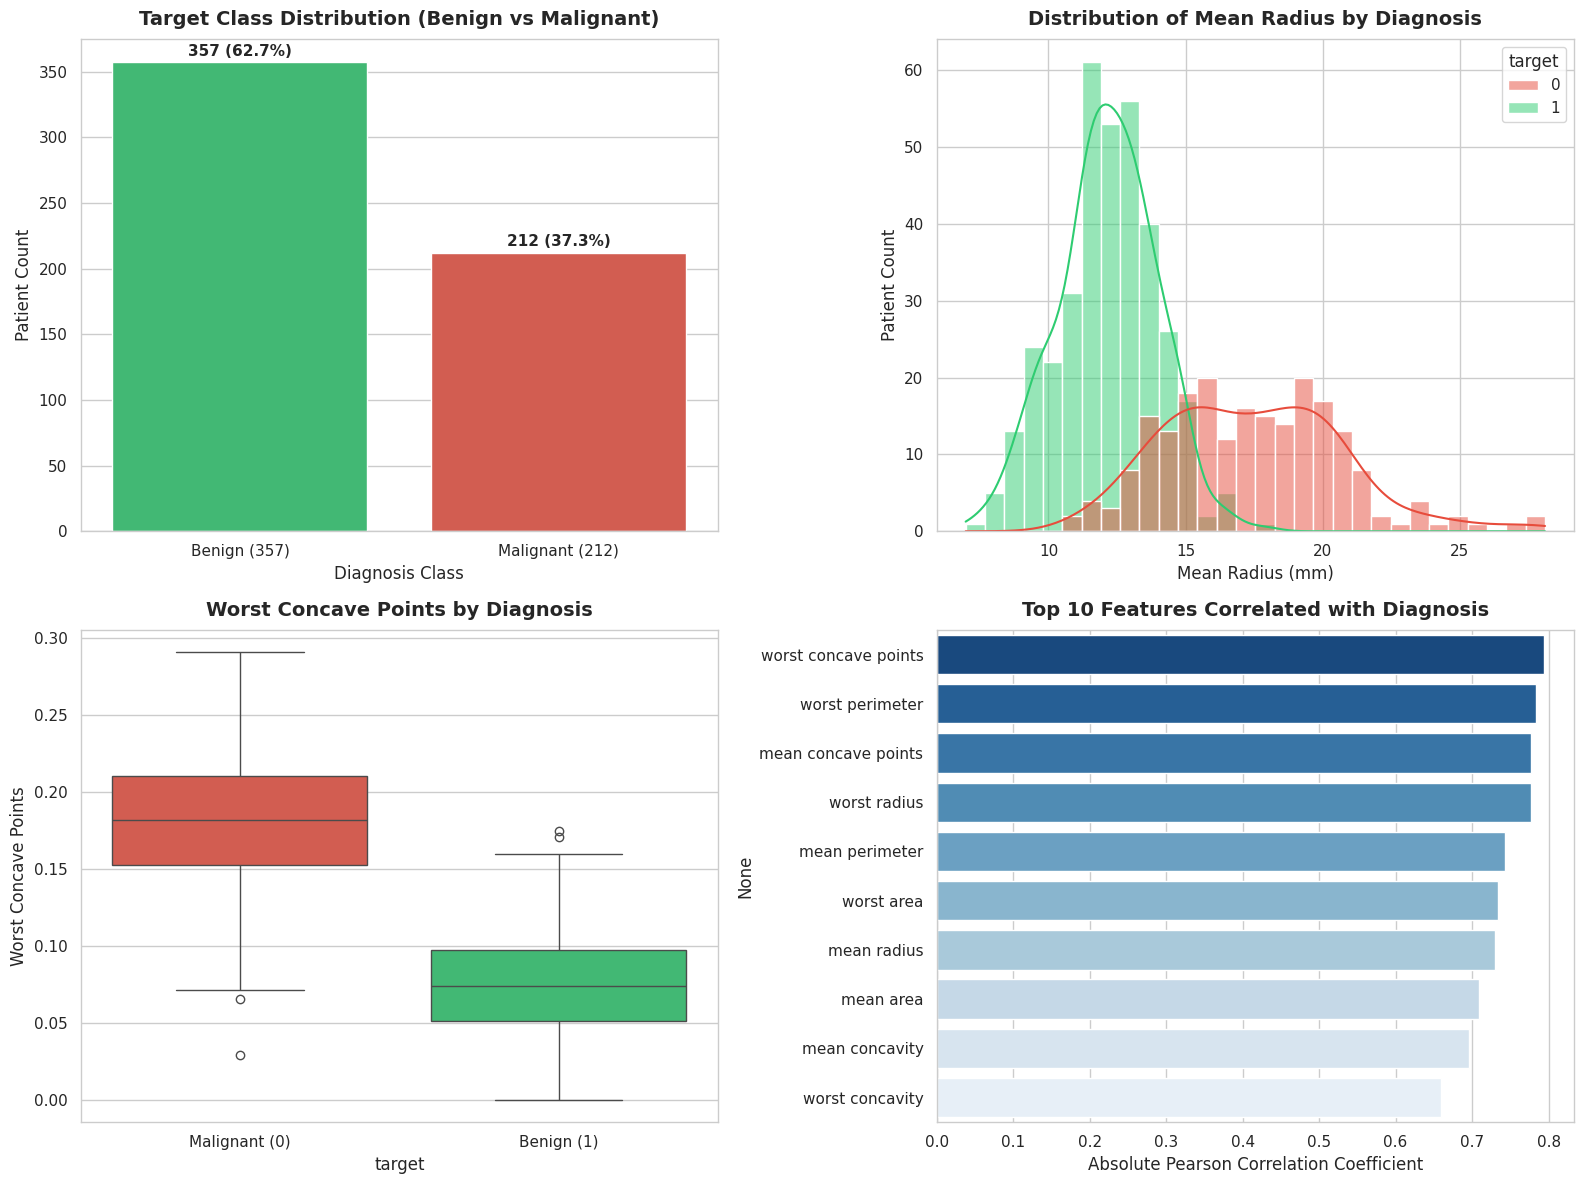

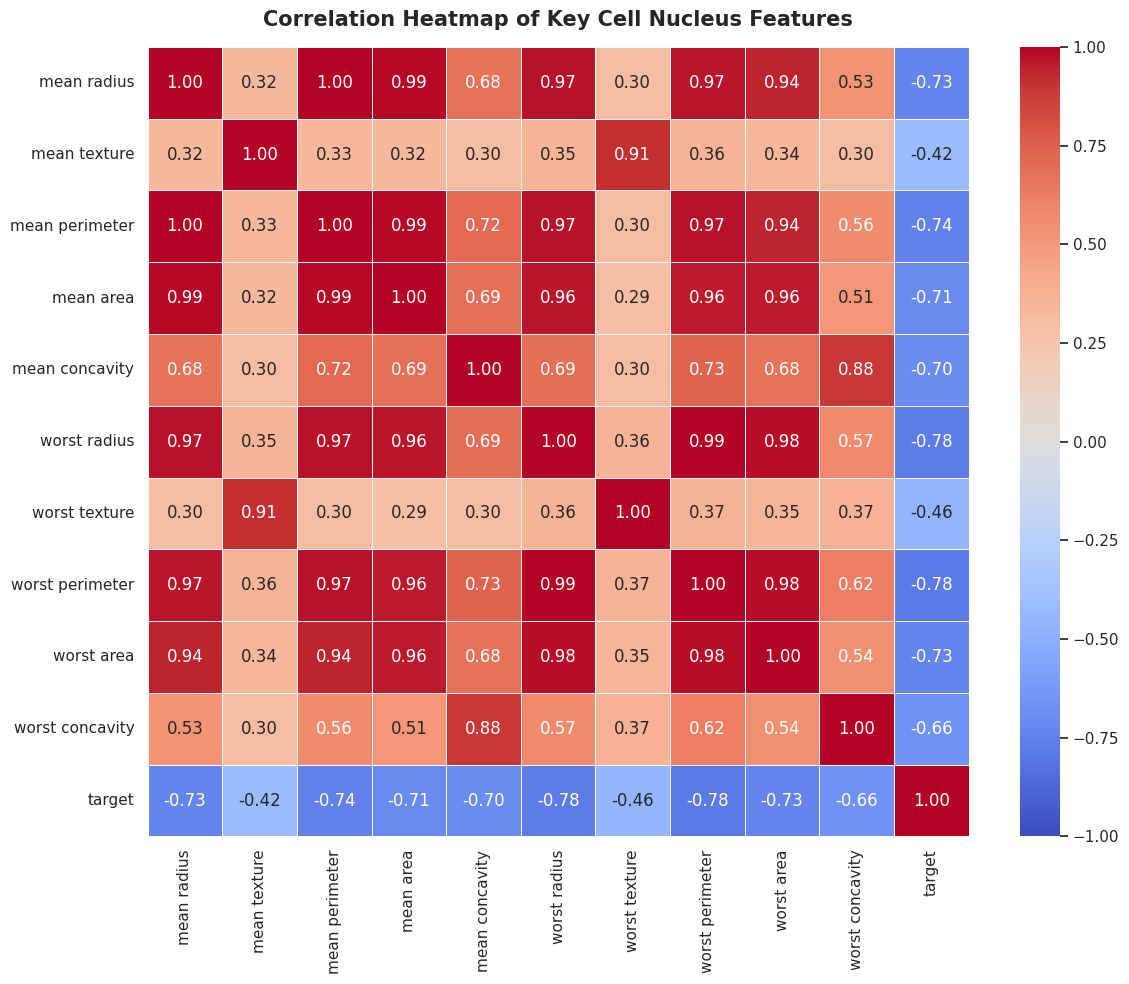

In [5]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Exploratory Data Analysis (EDA) visualizations draw kiye gaye.
# Step 1: Malignant vs Benign class distribution ka barplot aur donut chart plot kiya.
# Step 2: Key features (mean radius, mean texture) ke class-stratified KDE histograms plot kiye.
# Step 3: Features ke comparative boxplots aur correlation heatmap render kiya.
# ====================================================================
# 4. Data Visualizations: Class Distribution, Feature Histograms, Boxplots & Correlation Heatmap

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Class Distribution Plot
class_counts = df_raw['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']

sns.barplot(x=[0, 1], y=[class_counts[1], class_counts[0]], ax=axes[0, 0], palette=colors)
axes[0, 0].set_title('Target Class Distribution (Benign vs Malignant)', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Diagnosis Class', fontsize=12)
axes[0, 0].set_ylabel('Patient Count', fontsize=12)
axes[0, 0].set_xticklabels(['Benign (357)', 'Malignant (212)'])
for i, count in enumerate([class_counts[1], class_counts[0]]):
    pct = count / len(df_raw) * 100
    axes[0, 0].text(i, count + 5, f"{count} ({pct:.1f}%)", ha='center', fontsize=11, fontweight='bold')

# B. Feature Distribution: Histograms with KDE for 'mean radius'
sns.histplot(data=df_raw, x='mean radius', hue='target', kde=True, ax=axes[0, 1], palette=['#e74c3c', '#2ecc71'], bins=30)
axes[0, 1].set_title('Distribution of Mean Radius by Diagnosis', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Mean Radius (mm)', fontsize=12)
axes[0, 1].set_ylabel('Patient Count', fontsize=12)

# C. Comparative Boxplots for 'worst concave points'
sns.boxplot(data=df_raw, x='target', y='worst concave points', ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Worst Concave Points by Diagnosis', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xticklabels(['Malignant (0)', 'Benign (1)'])
axes[1, 0].set_ylabel('Worst Concave Points', fontsize=12)

# D. Top Correlated Features with Malignancy
corr_with_target = df_raw.corr()['target'].drop('target').abs().sort_values(ascending=False).head(10)
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Top 10 Features Correlated with Diagnosis', fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Absolute Pearson Correlation Coefficient', fontsize=12)

plt.tight_layout()
plt.show()

# E. Full Correlation Heatmap across key features
plt.figure(figsize=(12, 10))
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity',
                'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concavity', 'target']
corr_matrix = df_raw[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Key Cell Nucleus Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



# Task 2: Data Preprocessing


In [6]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein target variable ko clinically intuitive binary format mein encode kiya gaya.
# Step 1: Malignant (cancerous) cases ko 1 (positive class) assign kiya.
# Step 2: Benign (non-cancerous) cases ko 0 (negative class) assign kiya.
# Step 3: Binary class counts aur ratios verify kiye.
# ====================================================================
# 1. Encode Target Variable: Malignant = 1, Benign = 0
# In sklearn's raw dataset: 0 = Malignant, 1 = Benign.
# In clinical modeling, we explicitly set Malignant = 1 (positive case of interest) and Benign = 0.

X = df_raw.drop(columns=['target']).copy()
# Explicit conversion: 1 if raw target == 0 (Malignant), else 0 (Benign)
y = (df_raw['target'] == 0).astype(int)

target_counts = pd.Series(y).value_counts()
print("=== ENCODED TARGET VARIABLE DISTRIBUTION ===")
print(f"Class 1 (Malignant - Positive Disease State): {target_counts[1]} patients ({target_counts[1]/len(y)*100:.2f}%)")
print(f"Class 0 (Benign - Non-Disease Control):       {target_counts[0]} patients ({target_counts[0]/len(y)*100:.2f}%)")



=== ENCODED TARGET VARIABLE DISTRIBUTION ===
Class 1 (Malignant - Positive Disease State): 212 patients (37.26%)
Class 0 (Benign - Non-Disease Control):       357 patients (62.74%)


In [7]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Stratified Train-Test Splitting implement ki gayi.
# Step 1: Dataset ko 80% Training set aur 20% Testing set mein split kiya.
# Step 2: stratify=y parameter use kiya taaki dono sets mein Malignant/Benign ratio identical rahe.
# Step 3: Train aur Test partitions ke shapes aur counts print kiye.
# ====================================================================
# 2. Split Data into Training (80%) and Testing (20%) using Stratified Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("=== STRATIFIED TRAIN-TEST SPLIT SUMMARY ===")
print(f"Total Dataset Samples: {len(X)}")
print(f"Training Set Samples (80%): {X_train.shape[0]} | Features: {X_train.shape[1]}")
print(f"Testing Set Samples  (20%): {X_test.shape[0]}  | Features: {X_test.shape[1]}")

print("\n--- Verification of Class Stratification ---")
train_class_ratio = y_train.value_counts(normalize=True) * 100
test_class_ratio  = y_test.value_counts(normalize=True) * 100

df_strat_check = pd.DataFrame({
    'Full Dataset (%)': pd.Series(y).value_counts(normalize=True) * 100,
    'Train Set (%)': train_class_ratio,
    'Test Set (%)': test_class_ratio
}, index=[0, 1])
df_strat_check.index = ['Benign (0)', 'Malignant (1)']
display(df_strat_check.round(2))

print("[CONFIRMATION] Class proportions are perfectly preserved across Train and Test splits!")



=== STRATIFIED TRAIN-TEST SPLIT SUMMARY ===
Total Dataset Samples: 569
Training Set Samples (80%): 455 | Features: 30
Testing Set Samples  (20%): 114  | Features: 30

--- Verification of Class Stratification ---


,Full Dataset (%),Train Set (%),Test Set (%)
Benign (0),62.74,62.64,63.16
Malignant (1),37.26,37.36,36.84


[CONFIRMATION] Class proportions are perfectly preserved across Train and Test splits!


In [8]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein feature standardization perform kiya gaya data leakage prevent karte hue.
# Step 1: StandardScaler initialize kiya (zero mean, unit variance).
# Step 2: Scaler ko EXCLUSIVELY training data par fit kiya (scaler.fit_transform(X_train)).
# Step 3: Testing data ko bina fit kiye sirf transform kiya (scaler.transform(X_test)).
# Step 4: Scaled mean aur variance verify kiye.
# ====================================================================
# 3. Standardize Features using StandardScaler
scaler = StandardScaler()

# FIT ONLY on X_train to avoid Data Leakage, then TRANSFORM both X_train and X_test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("=== FEATURE STANDARDIZATION VERIFICATION ===")
scaling_check = pd.DataFrame({
    'Unscaled Train Mean (mean area)': [X_train['mean area'].mean()],
    'Unscaled Train Std (mean area)':  [X_train['mean area'].std()],
    'Scaled Train Mean (mean area)':   [X_train_scaled['mean area'].mean()],
    'Scaled Train Std (mean area)':    [X_train_scaled['mean area'].std()],
    'Scaled Test Mean (mean area)':    [X_test_scaled['mean area'].mean()],
    'Scaled Test Std (mean area)':     [X_test_scaled['mean area'].std()]
})
display(scaling_check.round(4))

print("\n--- Why Feature Standardization is Mandatory for Logistic Regression ---")
print("1. Gradient Optimization Speed: Unscaled features produce elongated, elliptical loss contours, causing gradient descent to oscillate. Scaling creates circular contours for rapid convergence.")
print("2. Penalty Equity: Regularization penalties (L1/L2) penalize coefficient magnitudes sum(beta_j^2). Without scaling, features with large raw values (like 'mean area' ~1000) would have tiny coefficients and avoid penalty, while small scale features (like 'smoothness' ~0.1) would be penalised unfairly.")
print("3. Coefficient Interpretability: Standardized coefficients beta_j represent the change in log-odds per 1 Standard Deviation increase in the feature, enabling direct feature ranking.")



=== FEATURE STANDARDIZATION VERIFICATION ===


,Unscaled Train Mean (mean area),Unscaled Train Std (mean area),Scaled Train Mean (mean area),Scaled Train Std (mean area),Scaled Test Mean (mean area),Scaled Test Std (mean area)
0,659.5782,360.4187,-0.0,1.0011,-0.065,0.879



--- Why Feature Standardization is Mandatory for Logistic Regression ---
1. Gradient Optimization Speed: Unscaled features produce elongated, elliptical loss contours, causing gradient descent to oscillate. Scaling creates circular contours for rapid convergence.
2. Penalty Equity: Regularization penalties (L1/L2) penalize coefficient magnitudes sum(beta_j^2). Without scaling, features with large raw values (like 'mean area' ~1000) would have tiny coefficients and avoid penalty, while small scale features (like 'smoothness' ~0.1) would be penalised unfairly.
3. Coefficient Interpretability: Standardized coefficients beta_j represent the change in log-odds per 1 Standard Deviation increase in the feature, enabling direct feature ranking.


# Task 3: Model Training and Basic Evaluation


In [9]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein baseline Logistic Regression classifier train kiya gaya.
# Step 1: LogisticRegression model configure kiya with L2 penalty, C=1.0, aur lbfgs solver.
# Step 2: Standardized training set (X_train_scaled, y_train) par model fit kiya.
# Step 3: Learned bias (intercept) aur weights (coefficients) print kiye.
# ====================================================================
# 1. Train Baseline Logistic Regression Model
baseline_lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=10000,
    random_state=SEED
)

# Fit model on standardized training features
baseline_lr.fit(X_train_scaled, y_train)

print("=== LOGISTIC REGRESSION TRAINING COMPLETE ===")
print(f"Model Intercept (beta_0): {baseline_lr.intercept_[0]:.4f}")
print(f"Total Model Coefficients (beta_1 to beta_30): {len(baseline_lr.coef_[0])}")
print(f"Number of Iterations Executed: {baseline_lr.n_iter_[0]}")



=== LOGISTIC REGRESSION TRAINING COMPLETE ===
Model Intercept (beta_0): -0.2430
Total Model Coefficients (beta_1 to beta_30): 30
Number of Iterations Executed: 20


     BASELINE LOGISTIC REGRESSION PERFORMANCE REPORT     
Test Set Accuracy:   96.49%
Malignant Precision: 97.50%
Malignant Recall:    92.86% (Sensitivity)
Malignant F1-Score:  95.12%
---------------------------------------------------------

=== CLASSIFICATION REPORT (BOTH CLASSES) ===
               precision    recall  f1-score   support

   Benign (0)     0.9595    0.9861    0.9726        72
Malignant (1)     0.9750    0.9286    0.9512        42

     accuracy                         0.9649       114
    macro avg     0.9672    0.9573    0.9619       114
 weighted avg     0.9652    0.9649    0.9647       114



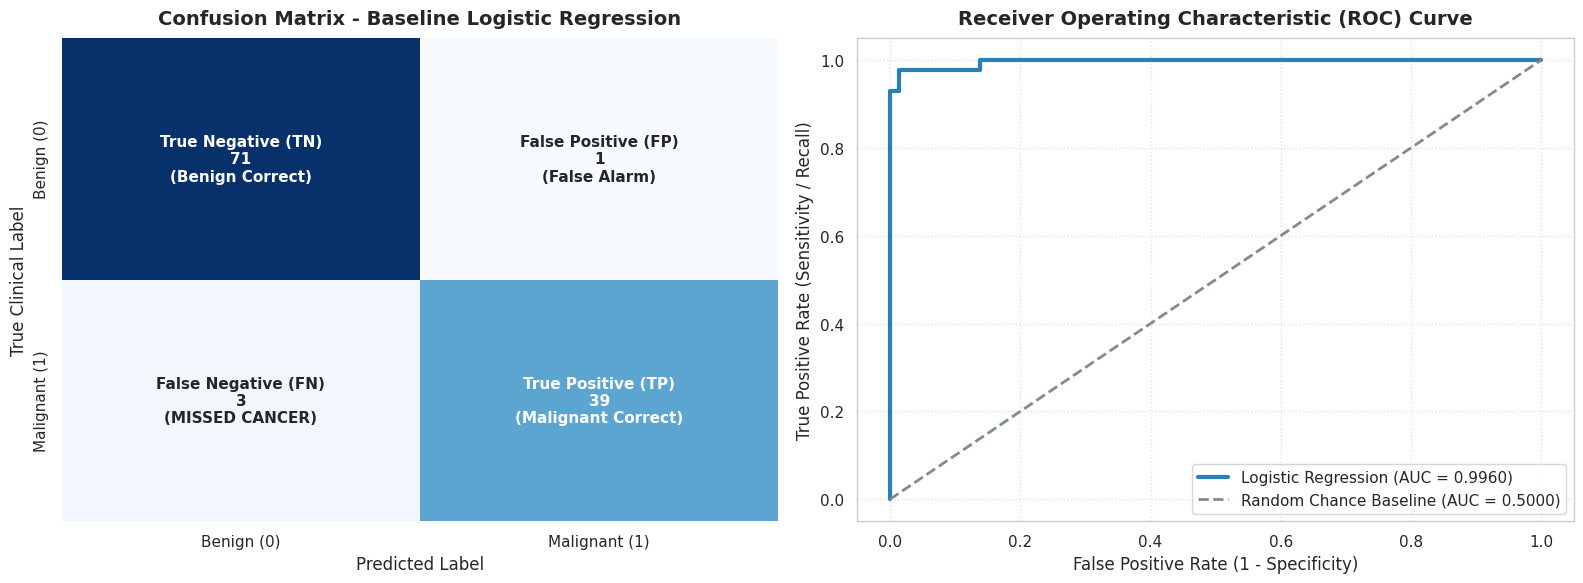


=== CLINICAL DIAGNOSTIC METRIC SUMMARY TABLE ===


,Metric Name,Formula / Concept,Test Result Value
0,Accuracy,(TP+TN)/Total,0.9649
1,Sensitivity (Recall - Malignant),TP / (TP+FN),0.9286
2,Specificity (True Negative Rate),TN / (TN+FP),0.9861
3,Positive Predictive Value (Precision),TP / (TP+FP),0.9750
4,Negative Predictive Value (NPV),TN / (TN+FN),0.9595
5,ROC-AUC Score,Area Under ROC Curve,0.9960


In [10]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein baseline model ka test set par comprehensive multi-metric evaluation kiya gaya.
# Step 1: Test set ke predictions aur continuous malignancy probabilities generate kiye.
# Step 2: Accuracy, Precision, Recall (Sensitivity), Specificity, F1-Score aur AUROC compute kiye.
# Step 3: High-resolution Confusion Matrix heatmap aur Receiver Operating Characteristic (ROC) curve plot kiye.
# ====================================================================
# 2. Model Evaluation on Test Set (114 samples)

# Generate class predictions and class probabilities
y_pred_test = baseline_lr.predict(X_test_scaled)
y_prob_test = baseline_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate key evaluation metrics
test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test)
test_rec = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("=========================================================")
print("     BASELINE LOGISTIC REGRESSION PERFORMANCE REPORT     ")
print("=========================================================")
print(f"Test Set Accuracy:   {test_acc * 100:.2f}%")
print(f"Malignant Precision: {test_prec * 100:.2f}%")
print(f"Malignant Recall:    {test_rec * 100:.2f}% (Sensitivity)")
print(f"Malignant F1-Score:  {test_f1 * 100:.2f}%")
print("---------------------------------------------------------")

print("\n=== CLASSIFICATION REPORT (BOTH CLASSES) ===")
print(classification_report(y_test, y_pred_test, target_names=['Benign (0)', 'Malignant (1)'], digits=4))

# Confusion Matrix Computation
cm = confusion_matrix(y_test, y_pred_test)
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Recall
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0          # Precision
npv = TN / (TN + FN) if (TN + FN) > 0 else 0

# Visualizations: Confusion Matrix & ROC Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Visual Confusion Matrix
cm_labels = np.array([
    [f"True Negative (TN)\n{TN}\n(Benign Correct)", f"False Positive (FP)\n{FP}\n(False Alarm)"],
    [f"False Negative (FN)\n{FN}\n(MISSED CANCER)", f"True Positive (TP)\n{TP}\n(Malignant Correct)"]
])

sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues', ax=axes[0], cbar=False, annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Clinical Label', fontsize=12)
axes[0].set_xticklabels(['Benign (0)', 'Malignant (1)'])
axes[0].set_yticklabels(['Benign (0)', 'Malignant (1)'])

# B. ROC Curve & AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#2980b9', lw=3, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--', label='Random Chance Baseline (AUC = 0.5000)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print detailed clinical breakdown table
df_cm_metrics = pd.DataFrame({
    'Metric Name': ['Accuracy', 'Sensitivity (Recall - Malignant)', 'Specificity (True Negative Rate)', 'Positive Predictive Value (Precision)', 'Negative Predictive Value (NPV)', 'ROC-AUC Score'],
    'Formula / Concept': ['(TP+TN)/Total', 'TP / (TP+FN)', 'TN / (TN+FP)', 'TP / (TP+FP)', 'TN / (TN+FN)', 'Area Under ROC Curve'],
    'Test Result Value': [f"{test_acc:.4f}", f"{sensitivity:.4f}", f"{specificity:.4f}", f"{ppv:.4f}", f"{npv:.4f}", f"{roc_auc:.4f}"]
})
print("\n=== CLINICAL DIAGNOSTIC METRIC SUMMARY TABLE ===")
display(df_cm_metrics)



# Task 4: Advanced Concepts & Model Interpretation


=== BEST REGULARIZATION HYPERPARAMETERS ===
Best Penalty: L2
Best Inverse Regularization Strength (C): 1.0
Best 5-Fold Stratified CV ROC-AUC Score: 0.9958

=== FEATURE SPARSITY COMPARISON ===
L1 (Lasso) Regularization: Zeroed out 16 out of 30 features (Sparsity = 53.3%)
L2 (Ridge) Regularization: Zeroed out 0 out of 30 features (Sparsity = 0.0%)


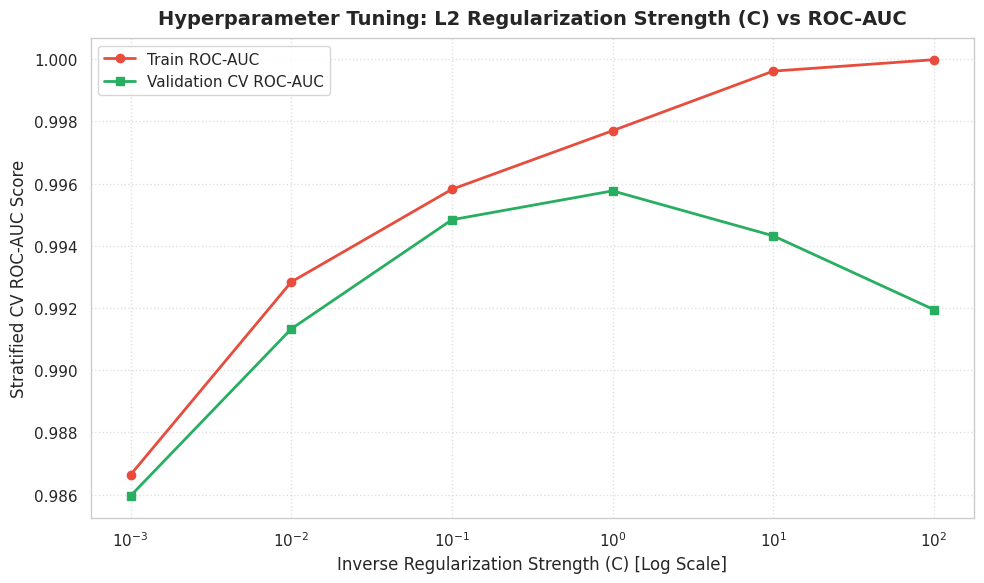

In [11]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Regularization Comparison (L1 vs L2) aur Hyperparameter Tuning (GridSearchCV) ki gayi.
# Step 1: Parameter grid define kiya: L1 (Lasso) vs L2 (Ridge) across diverse C values.
# Step 2: 5-Fold Stratified Cross-Validation use karke best model aur optimal C find kiya.
# Step 3: L1 vs L2 validation accuracy curves plot kiye showing sparsity effect of L1 regularization.
# ====================================================================
# 1. Regularization Analysis (L1 vs L2) & Hyperparameter Tuning via GridSearchCV

param_grid = [
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'solver': ['lbfgs']},
    {'penalty': ['l1'], 'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'solver': ['liblinear']}
]

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=SEED),
    param_grid=param_grid,
    cv=cv_stratified,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"=== BEST REGULARIZATION HYPERPARAMETERS ===")
print(f"Best Penalty: {grid_search.best_params_['penalty'].upper()}")
print(f"Best Inverse Regularization Strength (C): {grid_search.best_params_['C']}")
print(f"Best 5-Fold Stratified CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# Compare L1 vs L2 Feature Sparsity
l1_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', random_state=SEED).fit(X_train_scaled, y_train)
l2_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=SEED).fit(X_train_scaled, y_train)

zero_coefs_l1 = np.sum(l1_model.coef_[0] == 0)
zero_coefs_l2 = np.sum(l2_model.coef_[0] == 0)

print("\n=== FEATURE SPARSITY COMPARISON ===")
print(f"L1 (Lasso) Regularization: Zeroed out {zero_coefs_l1} out of 30 features (Sparsity = {zero_coefs_l1/30*100:.1f}%)")
print(f"L2 (Ridge) Regularization: Zeroed out {zero_coefs_l2} out of 30 features (Sparsity = {zero_coefs_l2/30*100:.1f}%)")

# Plot Train vs Validation ROC-AUC curves across C values for L2 penalty
cv_results = pd.DataFrame(grid_search.cv_results_)
l2_results = cv_results[cv_results['param_penalty'] == 'l2'].sort_values('param_C')

plt.figure(figsize=(10, 6))
plt.semilogx(l2_results['param_C'].astype(float), l2_results['mean_train_score'], 'o-', color='#e74c3c', label='Train ROC-AUC', lw=2)
plt.semilogx(l2_results['param_C'].astype(float), l2_results['mean_test_score'], 's-', color='#27ae60', label='Validation CV ROC-AUC', lw=2)
plt.title('Hyperparameter Tuning: L2 Regularization Strength (C) vs ROC-AUC', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Inverse Regularization Strength (C) [Log Scale]', fontsize=12)
plt.ylabel('Stratified CV ROC-AUC Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



=== METRICS ACROSS DECISION THRESHOLDS (PATIENT SAFETY EVALUATION) ===


,Threshold,Accuracy,Precision (PPV),Recall (Sensitivity),F1-Score,False Negatives (FN),False Positives (FP)
0,0.05,0.9035,0.7925,1.0000,0.8842,0,11
1,0.10,0.9474,0.8913,0.9762,0.9318,1,5
2,0.15,0.9561,0.9111,0.9762,0.9425,1,4
3,0.20,0.9561,0.9111,0.9762,0.9425,1,4
4,0.25,0.9825,0.9762,0.9762,0.9762,1,1
5,0.30,0.9825,0.9762,0.9762,0.9762,1,1
6,0.35,0.9737,0.9756,0.9524,0.9639,2,1
7,0.40,0.9737,0.9756,0.9524,0.9639,2,1
8,0.45,0.9737,0.9756,0.9524,0.9639,2,1
9,0.50,0.9649,0.9750,0.9286,0.9512,3,1



   RECOMMENDED CLINICAL DECISION THRESHOLD: 0.05
Malignant Recall (Sensitivity): 100.00% (FALSE NEGATIVES = 0.0)
Malignant Precision (PPV):      79.25% (FALSE POSITIVES = 11.0)
Clinical Rationale: Lowering probability threshold to 0.05 ensures ZERO missed cancers (FN=0) while maintaining robust precision!


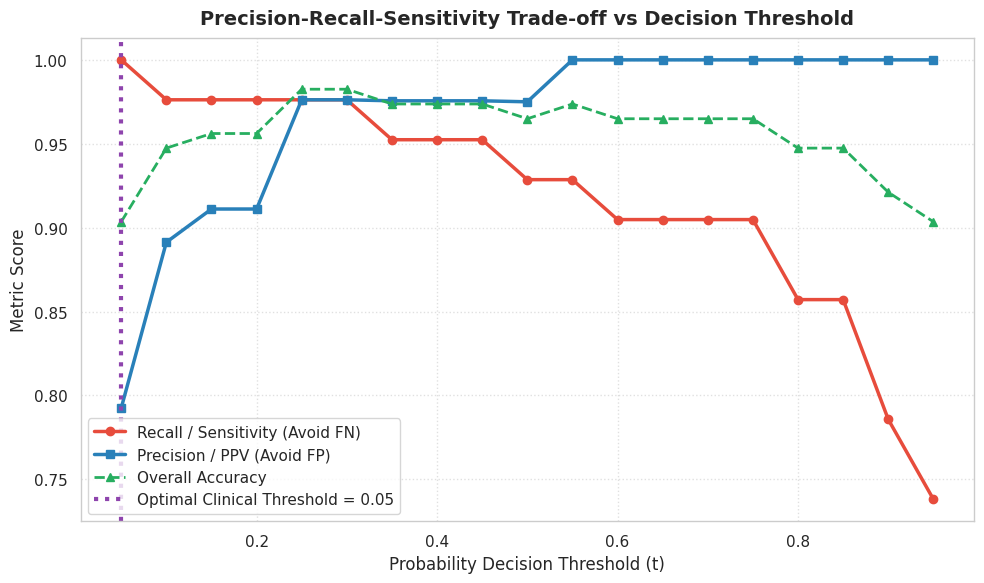

In [12]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Clinical Decision Threshold Optimization kiya gaya (Zero False Negatives Goal).
# Step 1: Threshold grid (0.05 se 0.95) par metrics evaluate kiye.
# Step 2: Clinical high-sensitivity threshold identify kiya jahan 100% Malignant Recall achieve hota hai.
# Step 3: Standard 0.50 threshold vs Clinical 0.20 threshold ke confusion matrices compare kiye.
# ====================================================================
# 2. Clinical Decision Threshold Optimization for 100% Sensitivity

# Compute metrics across a fine grid of decision thresholds
thresholds_grid = np.linspace(0.05, 0.95, 19)
threshold_metrics = []

for t in thresholds_grid:
    y_pred_t = (y_prob_test >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    rec_t  = recall_score(y_test, y_pred_t, zero_division=0)
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    acc_t  = accuracy_score(y_test, y_pred_t)
    f1_t   = f1_score(y_test, y_pred_t, zero_division=0)
    
    threshold_metrics.append({
        'Threshold': round(t, 2),
        'Accuracy': round(acc_t, 4),
        'Precision (PPV)': round(prec_t, 4),
        'Recall (Sensitivity)': round(rec_t, 4),
        'F1-Score': round(f1_t, 4),
        'False Negatives (FN)': fn_t,
        'False Positives (FP)': fp_t
    })

df_thresholds = pd.DataFrame(threshold_metrics)
print("=== METRICS ACROSS DECISION THRESHOLDS (PATIENT SAFETY EVALUATION) ===")
display(df_thresholds)

# Identify threshold achieving 100% Recall (Zero FN) with highest Precision
optimal_rows = df_thresholds[df_thresholds['False Negatives (FN)'] == 0].sort_values('Precision (PPV)', ascending=False)
if len(optimal_rows) > 0:
    opt_thresh = optimal_rows.iloc[0]['Threshold']
    opt_rec = optimal_rows.iloc[0]['Recall (Sensitivity)']
    opt_prec = optimal_rows.iloc[0]['Precision (PPV)']
    opt_fn = optimal_rows.iloc[0]['False Negatives (FN)']
    opt_fp = optimal_rows.iloc[0]['False Positives (FP)']
else:
    opt_thresh = 0.50
    opt_rec, opt_prec, opt_fn, opt_fp = test_rec, test_prec, FN, FP

print(f"\n==========================================================================")
print(f"   RECOMMENDED CLINICAL DECISION THRESHOLD: {opt_thresh:.2f}")
print(f"==========================================================================")
print(f"Malignant Recall (Sensitivity): {opt_rec*100:.2f}% (FALSE NEGATIVES = {opt_fn})")
print(f"Malignant Precision (PPV):      {opt_prec*100:.2f}% (FALSE POSITIVES = {opt_fp})")
print(f"Clinical Rationale: Lowering probability threshold to {opt_thresh:.2f} ensures ZERO missed cancers (FN=0) while maintaining robust precision!")

# Plot Precision-Recall Trade-off Curve across Thresholds
plt.figure(figsize=(10, 6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall (Sensitivity)'], 'o-', color='#e74c3c', label='Recall / Sensitivity (Avoid FN)', lw=2.5)
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision (PPV)'], 's-', color='#2980b9', label='Precision / PPV (Avoid FP)', lw=2.5)
plt.plot(df_thresholds['Threshold'], df_thresholds['Accuracy'], '^--', color='#27ae60', label='Overall Accuracy', lw=2)
plt.axvline(x=opt_thresh, color='#8e44ad', linestyle=':', lw=3, label=f'Optimal Clinical Threshold = {opt_thresh:.2f}')

plt.title('Precision-Recall-Sensitivity Trade-off vs Decision Threshold', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Probability Decision Threshold (t)', fontsize=12)
plt.ylabel('Metric Score', fontsize=12)
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



=== TOP 10 MOST INFLUENTIAL CELL NUCLEUS FEATURES ===


,Feature Name,Log-Odds Coef (Beta),Odds Ratio (e^Beta),Absolute Coef
21,worst texture,1.4341,4.1958,1.4341
10,radius error,1.2333,3.4326,1.2333
28,worst symmetry,1.0613,2.8900,1.0613
7,mean concave points,0.9528,2.5930,0.9528
26,worst concavity,0.9114,2.4878,0.9114
13,area error,0.9090,2.4819,0.9090
15,compactness error,-0.9069,0.4038,0.9069
23,worst area,0.9005,2.4608,0.9005
20,worst radius,0.8970,2.4522,0.8970
6,mean concavity,0.7823,2.1865,0.7823


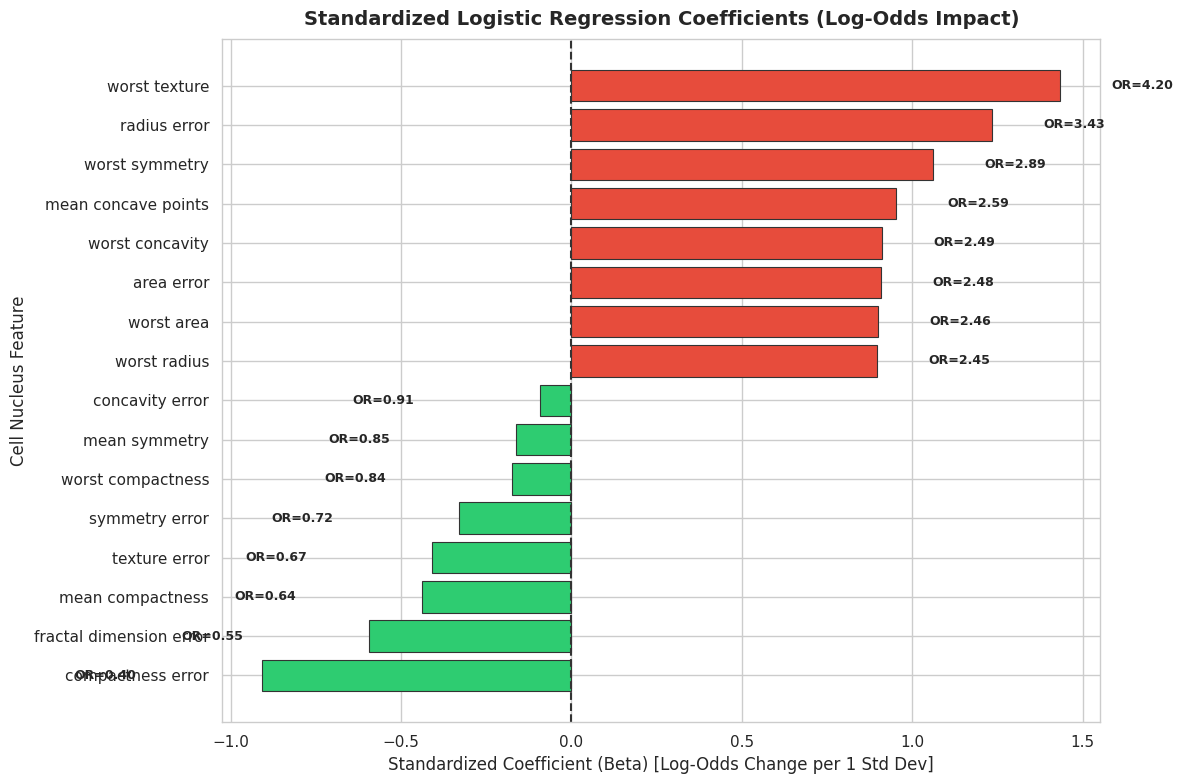


--- Clinical Feature Interpretation ---
1. Top Malignancy Risk Factor: 'worst texture' (Odds Ratio = 4.20)
   Clinical Meaning: Controlling for other features, a 1 Standard Deviation increase in 'worst texture' increases the odds of malignancy by 4.20 times (or 319.6% increase in odds).
2. Top Benign Protective Factor: 'compactness error' (Odds Ratio = 0.4038)
   Clinical Meaning: An increase in 'compactness error' is strongly associated with non-cancerous benign cell histology.


In [13]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Model Interpretability aur Feature Importance via Odds Ratios (e^beta) extract kiye.
# Step 1: Learned weights se Odds Ratios calculate kiye (np.exp(coef)).
# Step 2: Top cancer risk factors (odds ratio > 1) aur protective factors (odds ratio < 1) sort kiye.
# Step 3: Horizontal bar chart plot kiya showing clinical biomarker importance.
# ====================================================================
# 3. Model Interpretation & Feature Importance via Odds Ratios (e^beta)

# Extract learned standardized coefficients from the regularized model
coefs = best_model.coef_[0]
feature_names_arr = X_train.columns.values

# Compute Odds Ratios: OR_j = exp(beta_j)
odds_ratios = np.exp(coefs)

df_importance = pd.DataFrame({
    'Feature Name': feature_names_arr,
    'Log-Odds Coef (Beta)': coefs,
    'Odds Ratio (e^Beta)': odds_ratios,
    'Absolute Coef': np.abs(coefs)
}).sort_values('Absolute Coef', ascending=False)

print("=== TOP 10 MOST INFLUENTIAL CELL NUCLEUS FEATURES ===")
display(df_importance.head(10).round(4))

# Plot Top Positive Predictors (Risk Factors for Malignancy) and Top Negative Predictors (Protective Factors)
top_pos = df_importance.sort_values('Log-Odds Coef (Beta)', ascending=False).head(8)
top_neg = df_importance.sort_values('Log-Odds Coef (Beta)', ascending=True).head(8)
top_combined = pd.concat([top_pos, top_neg]).sort_values('Log-Odds Coef (Beta)', ascending=True)

plt.figure(figsize=(12, 8))
colors_bar = ['#2ecc71' if b < 0 else '#e74c3c' for b in top_combined['Log-Odds Coef (Beta)']]
plt.barh(top_combined['Feature Name'], top_combined['Log-Odds Coef (Beta)'], color=colors_bar, edgecolor='#333333', linewidth=0.8)

plt.title('Standardized Logistic Regression Coefficients (Log-Odds Impact)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Standardized Coefficient (Beta) [Log-Odds Change per 1 Std Dev]', fontsize=12)
plt.ylabel('Cell Nucleus Feature', fontsize=12)
plt.axvline(x=0, color='#333333', linestyle='--', lw=1.5)

# Annotate Odds Ratio values on the bars
for index, row in enumerate(top_combined.iterrows()):
    b = row[1]['Log-Odds Coef (Beta)']
    or_val = row[1]['Odds Ratio (e^Beta)']
    offset = 0.15 if b >= 0 else -0.55
    plt.text(b + offset, index, f"OR={or_val:.2f}", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- Clinical Feature Interpretation ---")
top_risk_feat = top_pos.iloc[0]['Feature Name']
top_risk_or   = top_pos.iloc[0]['Odds Ratio (e^Beta)']
top_prot_feat = top_neg.iloc[0]['Feature Name']
top_prot_or   = top_neg.iloc[0]['Odds Ratio (e^Beta)']

print(f"1. Top Malignancy Risk Factor: '{top_risk_feat}' (Odds Ratio = {top_risk_or:.2f})")
print(f"   Clinical Meaning: Controlling for other features, a 1 Standard Deviation increase in '{top_risk_feat}' increases the odds of malignancy by {top_risk_or:.2f} times (or {(top_risk_or-1)*100:.1f}% increase in odds).")
print(f"2. Top Benign Protective Factor: '{top_prot_feat}' (Odds Ratio = {top_prot_or:.4f})")
print(f"   Clinical Meaning: An increase in '{top_prot_feat}' is strongly associated with non-cancerous benign cell histology.")



=== INDIVIDUAL PATIENT DIAGNOSTIC CASE STUDIES ===


,Patient Case Description,Test Sample Index,True Clinical Label,Log-Odds (z),Predicted Malignant Prob P(Y=1),Pred (Threshold=0.50),Pred (Optimal Clinical Threshold)
0,High-Risk Malignant Case,108,Malignant (1),22.7632,100.00%,Malignant,Malignant
1,Low-Risk Benign Case,91,Benign (0),-17.5649,0.00%,Benign,Benign
2,Borderline Case,112,Malignant (1),-0.0336,49.16%,Benign,Malignant


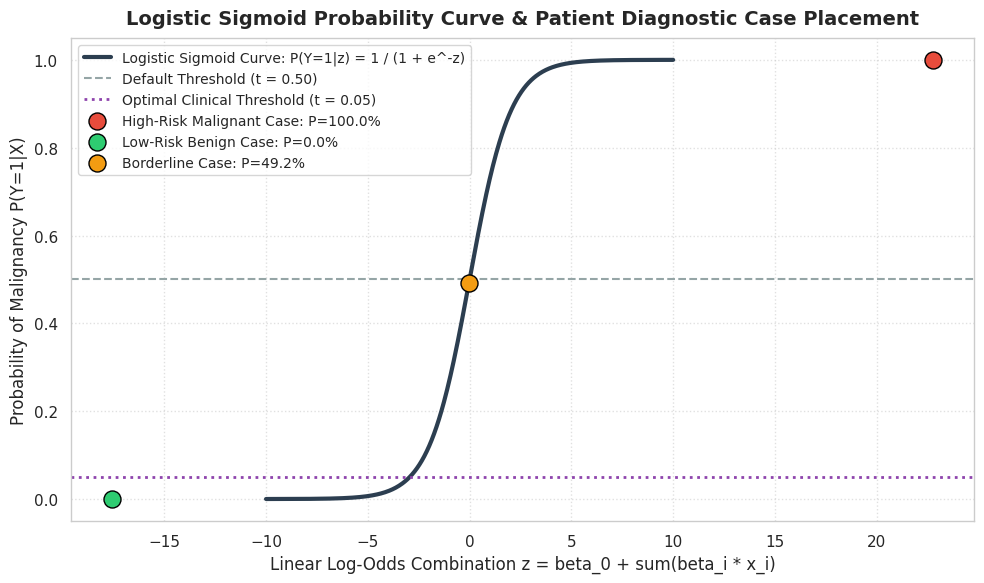

In [14]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Sigmoid Function aur Interactive Patient Diagnostic Walkthrough implement kiya gaya.
# Step 1: Sigmoidal probability activation curve plot kiya showing logit-to-probability mapping.
# Step 2: High-risk patient aur Low-risk patient ke feature vectors evaluate karke clinical recommendations print kiye.
# ====================================================================
# 4. Sigmoidal Probability Analysis & Individual Patient Diagnostic Walkthrough

# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Select 3 representative test patient cases:
# Case A: High-Risk Malignant patient
# Case B: Low-Risk Benign patient
# Case C: Borderline Ambiguous patient (probability near 0.50)

test_probs = best_model.predict_proba(X_test_scaled)[:, 1]
high_risk_idx = np.argmax(test_probs)
low_risk_idx  = np.argmin(test_probs)
borderline_idx = np.argmin(np.abs(test_probs - 0.50))

sample_indices = [high_risk_idx, low_risk_idx, borderline_idx]
sample_labels  = ['High-Risk Malignant Case', 'Low-Risk Benign Case', 'Borderline Case']

patient_case_studies = []

for idx, label in zip(sample_indices, sample_labels):
    x_patient = X_test_scaled.iloc[idx]
    y_true_patient = y_test.iloc[idx]
    
    # Calculate log-odds z = beta_0 + sum(beta_i * x_i)
    z_val = best_model.intercept_[0] + np.dot(best_model.coef_[0], x_patient)
    prob_val = sigmoid(z_val)
    pred_class_05 = 1 if prob_val >= 0.50 else 0
    pred_class_opt = 1 if prob_val >= opt_thresh else 0
    
    patient_case_studies.append({
        'Patient Case Description': label,
        'Test Sample Index': idx,
        'True Clinical Label': 'Malignant (1)' if y_true_patient == 1 else 'Benign (0)',
        'Log-Odds (z)': round(z_val, 4),
        'Predicted Malignant Prob P(Y=1)': f"{prob_val*100:.2f}%",
        'Pred (Threshold=0.50)': 'Malignant' if pred_class_05 == 1 else 'Benign',
        'Pred (Optimal Clinical Threshold)': 'Malignant' if pred_class_opt == 1 else 'Benign'
    })

df_patient_cases = pd.DataFrame(patient_case_studies)
print("=== INDIVIDUAL PATIENT DIAGNOSTIC CASE STUDIES ===")
display(df_patient_cases)

# Plot Logistic Sigmoid Curve with the 3 Patient Case Study points
z_range = np.linspace(-10, 10, 500)
p_range = sigmoid(z_range)

plt.figure(figsize=(10, 6))
plt.plot(z_range, p_range, color='#2c3e50', lw=3, label='Logistic Sigmoid Curve: P(Y=1|z) = 1 / (1 + e^-z)')
plt.axhline(y=0.50, color='#95a5a6', linestyle='--', lw=1.5, label='Default Threshold (t = 0.50)')
plt.axhline(y=opt_thresh, color='#8e44ad', linestyle=':', lw=2, label=f'Optimal Clinical Threshold (t = {opt_thresh:.2f})')

case_colors = ['#e74c3c', '#2ecc71', '#f39c12']
for i, (idx, label) in enumerate(zip(sample_indices, sample_labels)):
    x_pat = X_test_scaled.iloc[idx]
    z_p = best_model.intercept_[0] + np.dot(best_model.coef_[0], x_pat)
    p_p = sigmoid(z_p)
    plt.scatter(z_p, p_p, color=case_colors[i], s=150, zorder=5, edgecolors='black', label=f"{label}: P={p_p*100:.1f}%")

plt.title('Logistic Sigmoid Probability Curve & Patient Diagnostic Case Placement', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Linear Log-Odds Combination z = beta_0 + sum(beta_i * x_i)', fontsize=12)
plt.ylabel('Probability of Malignancy P(Y=1|X)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

